# Notebook 5 

This notebook will extend notebook 4 now to work with a potential in 2 dimensions $V(x,y) = (4 - x^2)^2 + y^2$ calculating the time spent to go from a minimum to another one

# Section 1

First beginning by brute force simulation

Transition detected at index: 403, time: 4.03


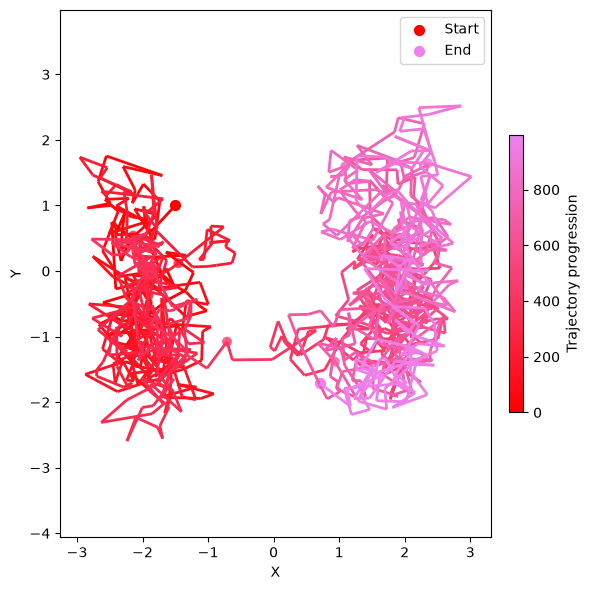

In [ ]:
import numpy as np
from src.abp_abf.potential import Potential
from src.abp_abf.transition_detector import TransitionDetector
from src.brownian import BrownianMotion


dt = 0.01
potential = Potential(1, lambda x: (4 - x[0] ** 2) ** 2 + x[1] ** 2, lambda x: np.array([-4 * x[0] * (4 - x[0] ** 2), 2 * x[1]]))
# Parameter D set to 4 so that the transition occurs in a reasonable time frame
bm = BrownianMotion(num_steps=1000, delta_t=dt, dimension=2, D=4, initial_position=np.array([-1.5, 1.0]), b=lambda x: -potential.potential_prime_at(x))
bm.simulate()

td = TransitionDetector(bm.positions, lambda x: x[0], 0.0)
transition_index = td.detect_transition()
transition_time = transition_index * dt if transition_index is not None else None

print(f"Transition detected at index: {transition_index}, time: {transition_time}")
bm.plot_brownian_path(bm.positions, point_stride=100)

# Section 2

ABP applied to the problem